In [1]:
# Install packages

# !pip -q install pandas numpy sqlalchemy psycopg2-binary statsmodels prophet matplotlib seaborn

In [2]:
# Imports and configuration

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg

try:
    from prophet import Prophet
except Exception:
    Prophet = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

FORECAST_HORIZON = 12
INITIAL_TRAIN_MONTHS = 24
ROLLING_HORIZON = 1
ROLLING_STEP = 1
SELECTION_HORIZON = FORECAST_HORIZON
START_DATE = "2022-01-01"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
INPUT_CSV = NOTEBOOK_DIR / "enquiry_training_raw_20260421_132507.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "enquiry_value_forecast"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

USE_EXPORTED_CSV = True

print("Project root:", PROJECT_ROOT)
print("Notebook dir:", NOTEBOOK_DIR)
print("Using exported CSV:", USE_EXPORTED_CSV)
print("Input CSV:", INPUT_CSV)
print("CSV exists:", INPUT_CSV.exists())
print("Prophet available:", Prophet is not None)
print("Output directory:", OUTPUT_DIR)
print("Forecast horizon:", FORECAST_HORIZON)
print("Selection horizon:", SELECTION_HORIZON)


c:\Users\SamuelOjuri\OneDrive - Tapered Plus\Documents\CodeProjects\DataCube\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\SamuelOjuri\OneDrive - Tapered Plus\Documents\CodeProjects\DataCube
Notebook dir: c:\Users\SamuelOjuri\OneDrive - Tapered Plus\Documents\CodeProjects\DataCube\notebooks
Using exported CSV: True
Input CSV: c:\Users\SamuelOjuri\OneDrive - Tapered Plus\Documents\CodeProjects\DataCube\notebooks\enquiry_training_raw_20260421_132507.csv
CSV exists: True
Prophet available: True
Output directory: c:\Users\SamuelOjuri\OneDrive - Tapered Plus\Documents\CodeProjects\DataCube\outputs\enquiry_value_forecast
Forecast horizon: 12
Selection horizon: 12


In [3]:
# Extract the raw project-level dataset

raw_df = pd.read_csv(INPUT_CSV)

raw_df["date_created"] = pd.to_datetime(
    raw_df["date_created"], format="mixed", dayfirst=True, errors="coerce"
)
raw_df["enquiry_month"] = raw_df["date_created"].dt.to_period("M").dt.to_timestamp()

raw_df["new_enquiry_value"] = pd.to_numeric(raw_df["new_enquiry_value"], errors="coerce").fillna(0.0)
raw_df["weighted_enquiry_value"] = pd.to_numeric(raw_df["weighted_enquiry_value"], errors="coerce").fillna(0.0)
raw_df["has_positive_value"] = pd.to_numeric(raw_df["has_positive_value"], errors="coerce").fillna(0).astype(int)

raw_df = raw_df[raw_df["date_created"] >= pd.Timestamp(START_DATE)].copy()

raw_df.head()

,project_id,item_name,project_name,date_created,enquiry_month,new_enquiry_value,gross_enquiry_value,has_positive_value,expected_conversion_rate,conversion_confidence,...,product_type_raw,value_band,pipeline_stage,status_category,zip_code,sales_representative,funding,analysis_timestamp,created_at,updated_at
1565,1775779400,11533,"SGN Depot, Horley Holder Site, Off Balcombe Ro...",2022-01-04,2022-01-01,33830.96,33830.96,1,0.16,1.00,...,Tissue Faced PIR,Medium (15-40k),Lost,Lost,RH,Eddie Bushe,Unknown,2026-03-31 01:27:44.920636+00:00,2025-09-13 17:56:27.602389+00:00,2026-03-30 17:23:58.976126+00:00
1566,1776934482,8625,73 Kenilworth Road,2022-01-04,2022-01-01,0.00,0.00,0,0.12,0.44,...,Tissue Faced PIR,Zero,Won - Closed (Invoiced),Won,Unknown,Unknown,Unknown,2026-03-31 01:36:29.381476+00:00,2025-09-15 00:20:40.834067+00:00,2026-03-30 17:25:42.646080+00:00
1567,1776934928,8624,86 Old Eign Hill Hereford,2022-01-04,2022-01-01,1346.95,1346.95,1,0.20,1.00,...,VIPs,Small (<15k),Lost,Lost,HR,Ian Sumner,Unknown,2026-03-31 01:36:30.089042+00:00,2025-09-15 00:20:40.834067+00:00,2026-03-30 17:25:42.752292+00:00
1568,1776936134,8622,"Abingdon School Boarding House, Park Road, Abi...",2022-01-04,2022-01-01,22953.29,22953.29,1,0.17,0.57,...,ROCKWOOL HardRock Multi-Fix (DD),Medium (15-40k),Open Enquiry,Open,OX,Eddie Bushe,Unknown,2026-04-15 17:09:17.736924+00:00,2025-09-15 00:20:40.834067+00:00,2026-04-15 17:09:05.318576+00:00
1569,1776931533,8633,"Prior Park School, Bath",2022-01-05,2022-01-01,20340.81,20340.81,1,0.19,1.00,...,Tissue Faced PIR,Medium (15-40k),Lost,Lost,Unknown,Deleted Devon Brown,Unknown,2026-03-31 01:36:27.676976+00:00,2025-09-15 00:05:05.906205+00:00,2026-03-30 17:25:42.310679+00:00


In [4]:
# Build the overall monthly dataset.

def build_overall_monthly(raw_frame: pd.DataFrame) -> pd.DataFrame:
    agg = (
        raw_frame.groupby("enquiry_month", as_index=False)
        .agg(
            enquiry_count_all=("project_id", "count"),
            enquiry_count_valued=("has_positive_value", "sum"),
            weighted_enquiry_value=("weighted_enquiry_value", "sum"),
        )
    )
    all_months = pd.date_range(
        agg["enquiry_month"].min(), agg["enquiry_month"].max(), freq="MS"
    )
    monthly = pd.DataFrame({"enquiry_month": all_months}).merge(
        agg, on="enquiry_month", how="left"
    )
    for col in ["enquiry_count_all", "enquiry_count_valued", "weighted_enquiry_value"]:
        monthly[col] = pd.to_numeric(monthly[col], errors="coerce").fillna(0.0)
    monthly["enquiry_count_all"] = monthly["enquiry_count_all"].astype(int)
    monthly["enquiry_count_valued"] = monthly["enquiry_count_valued"].astype(int)
    return monthly.sort_values("enquiry_month").reset_index(drop=True)


def drop_partial_last_month(monthly: pd.DataFrame, raw: pd.DataFrame) -> pd.DataFrame:
    last_month = monthly["enquiry_month"].max()
    month_end = (last_month + pd.offsets.MonthEnd(0)).normalize()
    latest_raw_date = raw["date_created"].max().normalize()
    if latest_raw_date < month_end:
        print(f"Dropping partial last month {last_month.date()} "
              f"(raw data ends on {latest_raw_date.date()}).")
        return monthly[monthly["enquiry_month"] < last_month].reset_index(drop=True)
    return monthly


overall_monthly = drop_partial_last_month(build_overall_monthly(raw_df), raw_df)
overall_monthly.to_csv(OUTPUT_DIR / "overall_monthly.csv", index=False)

print("Monthly rows:", len(overall_monthly))
overall_monthly.head()

Dropping partial last month 2026-04-01 (raw data ends on 2026-04-21).
Monthly rows: 51


,enquiry_month,enquiry_count_all,enquiry_count_valued,weighted_enquiry_value
0,2022-01-01,123,94,358148.6598
1,2022-02-01,157,111,909122.8092
2,2022-03-01,176,138,437571.4248
3,2022-04-01,147,111,404561.5756
4,2022-05-01,193,144,642002.2067


In [5]:
# Exploratory data analysis

print("Raw rows:", len(raw_df))
print("Date range:", raw_df["date_created"].min().date(), "to", raw_df["date_created"].max().date())
print("Unique accounts:", raw_df["account"].nunique())
print("Unique types:", raw_df["type"].nunique())
print("Unique categories:", raw_df["category"].nunique())
print("Unique product keys:", raw_df["product_key"].nunique())

display(
    raw_df[["new_enquiry_value"]]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .T
)

print("Zero weighted-value months:", int((overall_monthly["weighted_enquiry_value"] == 0).sum()))
print("Share of zero weighted-value months:", round((overall_monthly["weighted_enquiry_value"] == 0).mean() * 100, 2), "%")

def top_segments(raw_frame, col, top_n=10):
    return (
        raw_frame.groupby(col, dropna=False)
        .agg(
            projects=("project_id", "count"),
            total_value=("new_enquiry_value", "sum"),
        )
        .sort_values("total_value", ascending=False)
        .head(top_n)
    )

display(top_segments(raw_df, "type"))
display(top_segments(raw_df, "category"))
display(top_segments(raw_df, "product_key"))

Raw rows: 6864
Date range: 2022-01-04 to 2026-04-21
Unique accounts: 959
Unique types: 3
Unique categories: 14
Unique product keys: 13


,count,mean,std,min,50%,75%,90%,95%,99%,max
new_enquiry_value,6864.0,32661.051167,88564.047441,0.0,9188.545,29544.4975,75286.085,130521.2405,367308.6728,2257869.87


Zero weighted-value months: 0
Share of zero weighted-value months: 0.0 %


,projects,total_value
type,,
New Build,4128,1.512805e+08
Refurbishment,2705,7.258934e+07
Unknown,31,3.156071e+05


,projects,total_value
category,,
Apartments,2219,68251602.94
Education,1118,39652248.68
Commercial,929,32378493.65
Health,508,20743768.94
Datacentre,77,15537673.75
Leisure,440,14634471.85
Industrial,192,12634871.12
House,1059,10405418.14
Mixed Use,183,4675252.04


,projects,total_value
product_key,,
hardrock,1610,1.151493e+08
pir_tissue,2943,5.511883e+07
pir_prebonded,845,1.471938e+07
pir_torchon,557,1.272563e+07
t3_system,69,7.409245e+06
rockdeck,77,5.882572e+06
pir_foil,318,4.906555e+06
vips,169,3.306943e+06
eps_pir_composite,141,2.314050e+06


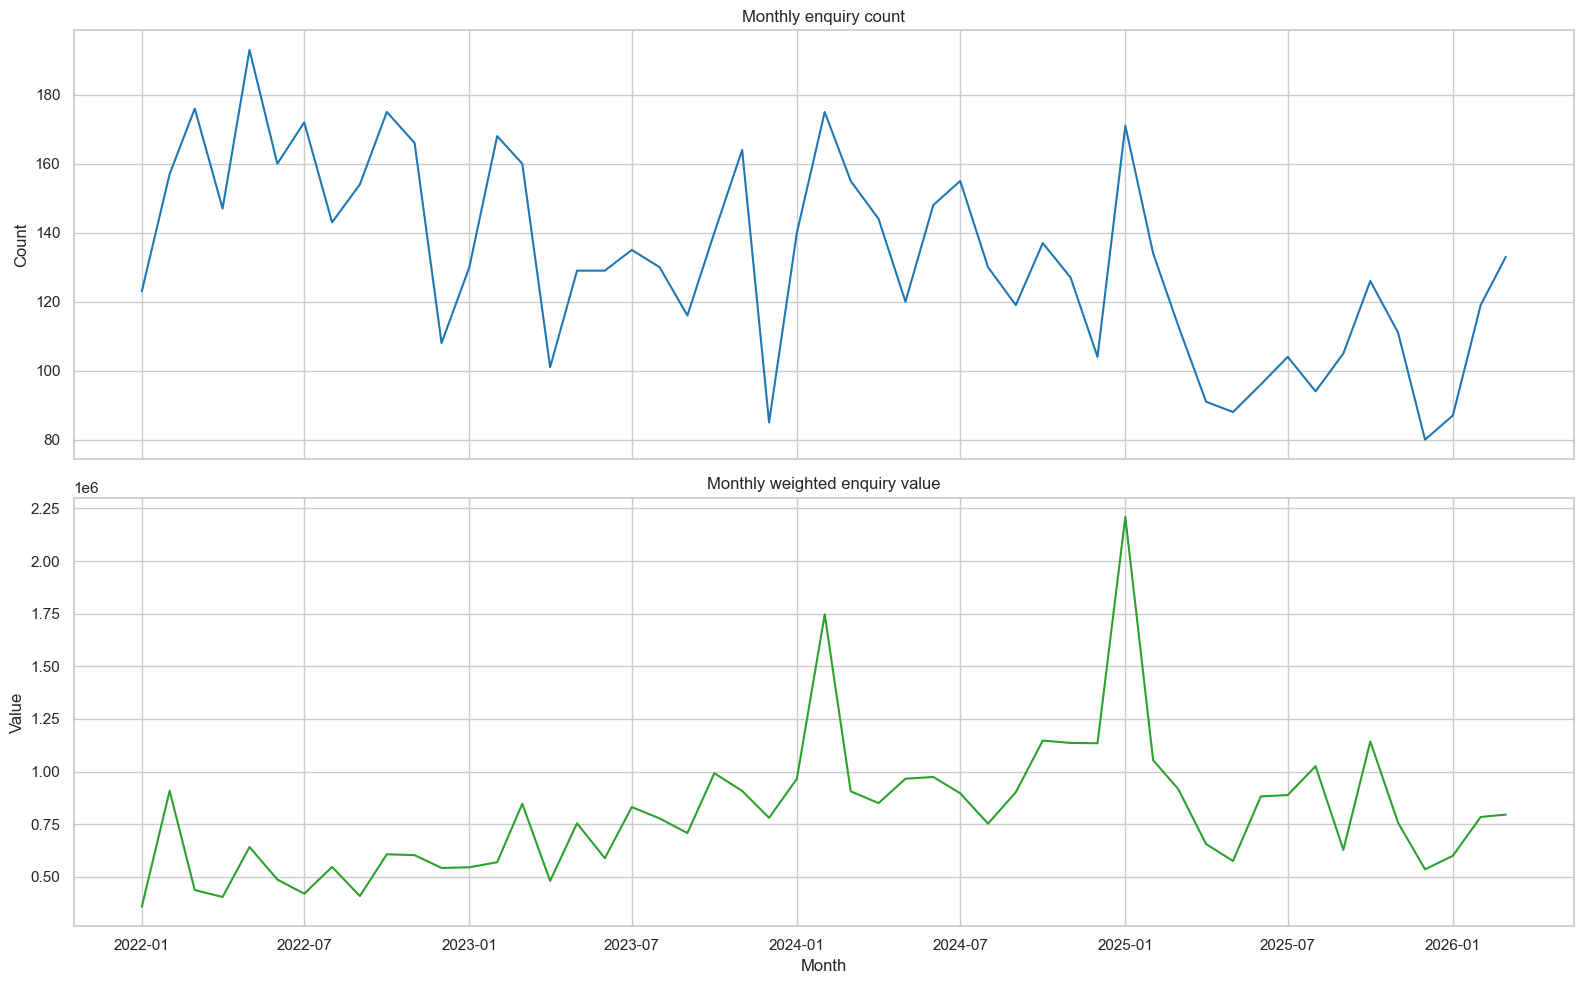

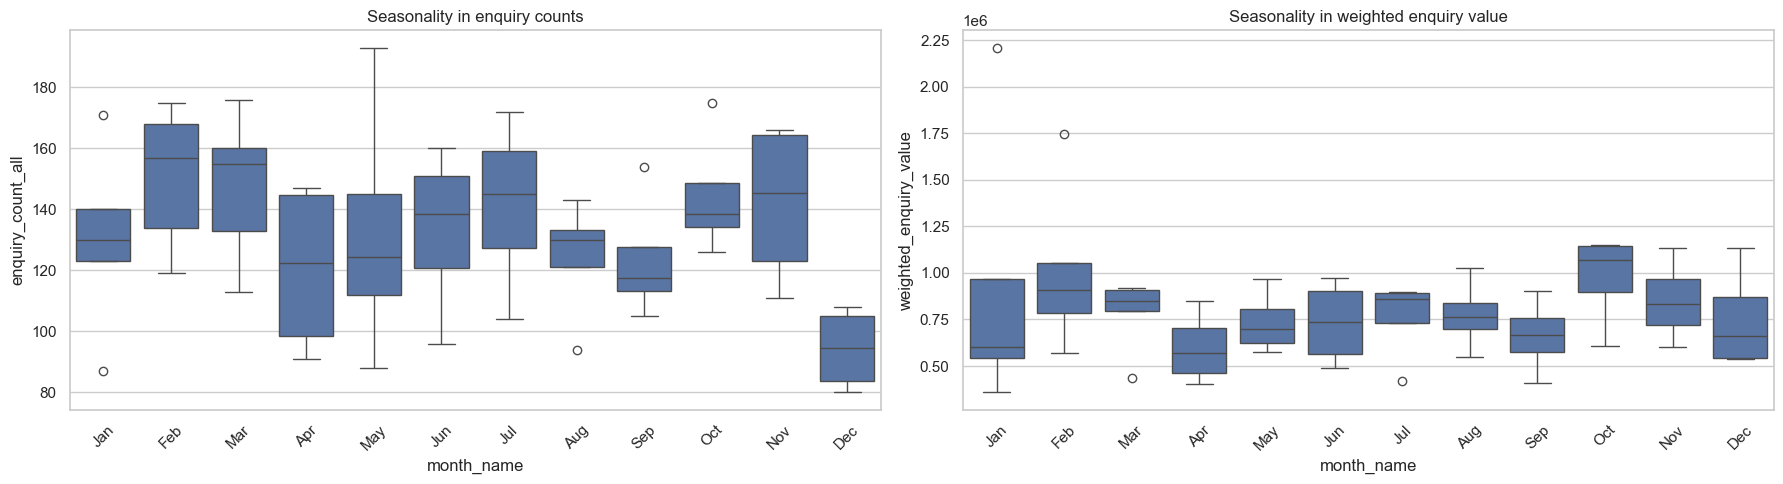

In [6]:
# Plot the overall historical series

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(overall_monthly["enquiry_month"], overall_monthly["enquiry_count_all"], color="tab:blue")
axes[0].set_title("Monthly enquiry count")
axes[0].set_ylabel("Count")

axes[1].plot(overall_monthly["enquiry_month"], overall_monthly["weighted_enquiry_value"], color="tab:green")
axes[1].set_title("Monthly weighted enquiry value")
axes[1].set_ylabel("Value")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

eda = overall_monthly.copy()
eda["month_name"] = eda["enquiry_month"].dt.strftime("%b")
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.boxplot(data=eda, x="month_name", y="enquiry_count_all", order=month_order, ax=axes[0])
axes[0].set_title("Seasonality in enquiry counts")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=eda, x="month_name", y="weighted_enquiry_value", order=month_order, ax=axes[1])
axes[1].set_title("Seasonality in weighted enquiry value")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# Forecasting, rolling-origin validation, and metrics

def non_negative(series):
    return pd.Series(np.clip(np.asarray(series, dtype=float), 0, None), index=series.index)

def metric_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def metric_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def metric_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def metric_smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(200 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]))

def score_prediction_frame(pred_frame):
    y_true = pred_frame["actual"].values
    y_pred = pred_frame["pred"].values
    return {
        "rmse": metric_rmse(y_true, y_pred),
        "mae": metric_mae(y_true, y_pred),
        "mape": metric_mape(y_true, y_pred),
        "smape": metric_smape(y_true, y_pred),
        "n_predictions": len(pred_frame),
    }

def seasonal_average_forecast(train, future_index, lookback=None, month_bias=False):
    train = train.astype(float)
    working = train.iloc[-lookback:] if lookback else train
    month_means = working.groupby(working.index.month).mean()
    global_mean = float(working.mean())
    pred = pd.Series(
        [month_means.get(ts.month, global_mean) for ts in future_index],
        index=future_index,
        dtype=float,
    )

    if month_bias and len(train) >= 24:
        fitted = pd.Series(
            [month_means.get(ts.month, global_mean) for ts in train.index],
            index=train.index,
            dtype=float,
        )
        bias = (train - fitted).groupby(train.index.month).mean()
        pred = pred + pd.Series(
            [bias.get(ts.month, 0.0) for ts in future_index],
            index=future_index,
            dtype=float,
        )

    return non_negative(pred)

def ets_forecast(train, future_index, trend=None, damped=False, seasonal="add", use_log=False, month_bias=False, remove_bias=False):
    train = train.astype(float)

    if seasonal == "mul" and (train <= 0).any():
        raise ValueError("Multiplicative ETS requires strictly positive training data.")

    model_series = np.log1p(train) if use_log else train

    model = ExponentialSmoothing(
        model_series,
        trend=trend,
        damped_trend=damped if trend is not None else False,
        seasonal=seasonal,
        seasonal_periods=12,
        initialization_method="estimated",
    )
    fit = model.fit(optimized=True, use_brute=True, remove_bias=remove_bias)

    pred_raw = fit.forecast(len(future_index))
    if use_log:
        resid = model_series - fit.fittedvalues
        sigma2 = float(np.nanvar(resid, ddof=1)) if len(resid) > 1 else 0.0
        pred = np.expm1(pred_raw + 0.5 * sigma2)
        fitted_back = np.expm1(fit.fittedvalues + 0.5 * sigma2)
    else:
        pred = pred_raw
        fitted_back = fit.fittedvalues

    pred = pd.Series(np.asarray(pred, dtype=float), index=future_index)
    fitted_back = pd.Series(np.asarray(fitted_back, dtype=float), index=train.index)

    if month_bias:
        bias = (train - fitted_back).groupby(train.index.month).mean()
        pred = pred + pd.Series(
            [bias.get(ts.month, 0.0) for ts in future_index],
            index=future_index,
            dtype=float,
        )

    return non_negative(pred)

def autoreg_forecast(train, future_index):
    if len(train) < 36:
        return seasonal_average_forecast(train, future_index)
    try:
        lag = min(12, max(3, len(train) // 4))
        model = AutoReg(train.astype(float), lags=lag, old_names=False)
        fit = model.fit()
        pred = fit.predict(start=len(train), end=len(train) + len(future_index) - 1, dynamic=False)
        pred.index = future_index
        return non_negative(pred.astype(float))
    except Exception:
        return seasonal_average_forecast(train, future_index)

def prophet_forecast(train, future_index):
    if Prophet is None or len(train) < 24:
        return seasonal_average_forecast(train, future_index)

    train = train.astype(float)
    train_df = pd.DataFrame({"ds": train.index, "y": train.values.astype(float)})
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=0.1,
        interval_width=0.8,
    )
    model.fit(train_df)
    future = pd.DataFrame({"ds": future_index})
    forecast = model.predict(future)
    pred = pd.Series(forecast["yhat"].values, index=future_index, dtype=float)
    return non_negative(pred)

def rolling_origin_predictions(series, forecaster, model_name, initial_train=24, horizon=1, step=1):
    series = series.asfreq("MS").fillna(0.0)
    rows = []

    for train_end in range(initial_train, len(series) - horizon + 1, step):
        train = series.iloc[:train_end]
        test = series.iloc[train_end:train_end + horizon]
        pred = forecaster(train, test.index)

        for ds, actual, yhat in zip(test.index, test.values, pred.values):
            rows.append({
                "date": ds,
                "actual": float(actual),
                "pred": float(yhat),
                "model": model_name,
                "train_end": train.index.max(),
            })

    return pd.DataFrame(rows)

def make_seasonal_average_candidates():
    candidates = {}
    for lookback in [12, 24, 36, None]:
        for month_bias in [False, True]:
            config = {"lookback": lookback, "month_bias": month_bias}
            label = f"seasonal_average|{json.dumps(config, sort_keys=True)}"
            candidates[label] = {
                "family": "seasonal_average",
                "config": config,
                "forecaster": (
                    lambda train, future_index, lb=lookback, mb=month_bias:
                    seasonal_average_forecast(train, future_index, lookback=lb, month_bias=mb)
                ),
            }
    return candidates

def make_ets_candidates(use_log):
    candidates = {}
    for trend in [None, "add"]:
        damped_options = [False] if trend is None else [False, True]
        for damped in damped_options:
            for seasonal in ["add", "mul"]:
                for month_bias in [False, True]:
                    for remove_bias in [False, True]:
                        config = {
                            "trend": trend,
                            "damped": damped,
                            "seasonal": seasonal,
                            "month_bias": month_bias,
                            "remove_bias": remove_bias,
                            "use_log": use_log,
                        }
                        label = f"ets|{json.dumps(config, sort_keys=True)}"
                        candidates[label] = {
                            "family": "ets",
                            "config": config,
                            "forecaster": (
                                lambda train, future_index, tr=trend, d=damped, s=seasonal, mb=month_bias, rb=remove_bias, ul=use_log:
                                ets_forecast(
                                    train,
                                    future_index,
                                    trend=tr,
                                    damped=d,
                                    seasonal=s,
                                    use_log=ul,
                                    month_bias=mb,
                                    remove_bias=rb,
                                )
                            ),
                        }
    return candidates

def make_candidate_dict(ets_use_log=False):
    candidates = {}
    candidates.update(make_seasonal_average_candidates())
    candidates.update(make_ets_candidates(use_log=ets_use_log))
    candidates["autoreg"] = {
        "family": "autoreg",
        "config": {},
        "forecaster": autoreg_forecast,
    }
    candidates["prophet"] = {
        "family": "prophet",
        "config": {},
        "forecaster": prophet_forecast,
    }
    return candidates

def evaluate_models(series, initial_train=24, horizon=1, step=1, ets_use_log=False):
    candidate_dict = make_candidate_dict(ets_use_log=ets_use_log)

    score_rows = []
    pred_frames = []
    failures = []

    for label, candidate in candidate_dict.items():
        try:
            pred_frame = rolling_origin_predictions(
                series=series,
                forecaster=candidate["forecaster"],
                model_name=label,
                initial_train=initial_train,
                horizon=horizon,
                step=step,
            )
            metrics = score_prediction_frame(pred_frame)
            metrics["model"] = label
            metrics["model_label"] = label
            metrics["family"] = candidate["family"]
            metrics["config_json"] = json.dumps(candidate["config"], sort_keys=True)
            score_rows.append(metrics)
            pred_frames.append(pred_frame)
        except Exception as exc:
            failures.append({"model_label": label, "family": candidate["family"], "error": repr(exc)})

    if not score_rows:
        raise RuntimeError("No candidate models completed successfully.")

    scores = pd.DataFrame(score_rows)
    for metric in ["rmse", "mae", "mape", "smape"]:
        scores[f"rank_{metric}"] = scores[metric].rank(method="min", na_option="bottom")
    scores["avg_rank"] = scores[[f"rank_{m}" for m in ["rmse", "mae", "mape", "smape"]]].mean(axis=1)
    scores = scores.sort_values(["avg_rank", "rmse", "mae", "mape", "smape", "model"]).reset_index(drop=True)

    pred_df = pd.concat(pred_frames, ignore_index=True)
    if failures:
        print(f"Skipped {len(failures)} candidate(s) due to fitting errors.")
    return scores, pred_df, candidate_dict

def best_by_family(scores):
    return (
        scores.sort_values(["avg_rank", "rmse", "mae", "mape", "smape", "model"])
        .groupby("family", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

def best_family_backtest_preds(preds, family_best):
    label_map = family_best.set_index("model_label")["family"].to_dict()
    out = preds[preds["model"].isin(label_map)].copy()
    out["model"] = out["model"].map(label_map)
    return out

def plot_backtest(actual_series, pred_df, title):
    plt.figure(figsize=(16, 5))
    plt.plot(actual_series.index, actual_series.values, color="black", linewidth=2, label="Actual")

    for model_name, group in pred_df.groupby("model"):
        line = group.groupby("date", as_index=True)["pred"].mean().sort_index()
        plt.plot(line.index, line.values, linewidth=1.5, label=model_name)

    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_residual_diagnostics(pred_df, best_model, title_prefix):
    best = pred_df[pred_df["model"] == best_model].copy()
    best["residual"] = best["actual"] - best["pred"]
    best["month_name"] = pd.to_datetime(best["date"]).dt.strftime("%b")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(best["residual"], bins=20, kde=True, ax=axes[0])
    axes[0].set_title(f"{title_prefix}: residual distribution")

    axes[1].scatter(best["pred"], best["actual"], alpha=0.7)
    min_v = min(best["pred"].min(), best["actual"].min())
    max_v = max(best["pred"].max(), best["actual"].max())
    axes[1].plot([min_v, max_v], [min_v, max_v], linestyle="--", color="red")
    axes[1].set_title(f"{title_prefix}: actual vs predicted")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    sns.boxplot(data=best, x="month_name", y="residual", order=month_order, ax=axes[2])
    axes[2].set_title(f"{title_prefix}: residual by month")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

def final_forecast(series, forecaster, model_name, backtest_df, horizon=12):
    series = series.asfreq("MS").fillna(0.0)
    future_index = pd.date_range(series.index.max() + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")
    pred = forecaster(series, future_index)

    model_backtest = backtest_df[backtest_df["model"] == model_name].copy()
    residual_std = (model_backtest["actual"] - model_backtest["pred"]).std(ddof=1)
    if pd.isna(residual_std):
        residual_std = 0.0

    lower = non_negative(pred - 1.96 * residual_std)
    upper = non_negative(pred + 1.96 * residual_std)

    forecast_df = pd.DataFrame({
        "date": future_index,
        "forecast": pred.values,
        "lower": lower.values,
        "upper": upper.values,
        "model": model_name,
    })
    return forecast_df

def plot_final_forecast(history, forecast_df, title):
    plt.figure(figsize=(16, 5))
    plt.plot(history.index, history.values, color="black", linewidth=2, label="History")
    plt.plot(forecast_df["date"], forecast_df["forecast"], color="tab:blue", linewidth=2, label="Forecast")
    plt.fill_between(
        forecast_df["date"],
        forecast_df["lower"],
        forecast_df["upper"],
        color="tab:blue",
        alpha=0.20,
        label="Forecast band",
    )
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [8]:
# Evaluate overall monthly enquiry count and weighted enquiry value

count_series = overall_monthly.set_index("enquiry_month")["enquiry_count_all"].astype(float)
value_series = overall_monthly.set_index("enquiry_month")["weighted_enquiry_value"].astype(float)

count_scores, count_preds, count_candidates = evaluate_models(
    count_series,
    initial_train=INITIAL_TRAIN_MONTHS,
    horizon=SELECTION_HORIZON,
    step=ROLLING_STEP,
    ets_use_log=False,
)

value_scores, value_preds, value_candidates = evaluate_models(
    value_series,
    initial_train=INITIAL_TRAIN_MONTHS,
    horizon=SELECTION_HORIZON,
    step=ROLLING_STEP,
    ets_use_log=True,
)

count_scores.to_csv(OUTPUT_DIR / "overall_count_model_scores.csv", index=False)
value_scores.to_csv(OUTPUT_DIR / "overall_value_model_scores.csv", index=False)
count_preds.to_csv(OUTPUT_DIR / "overall_count_backtest_predictions.csv", index=False)
value_preds.to_csv(OUTPUT_DIR / "overall_value_backtest_predictions.csv", index=False)

display(count_scores.head(10))
display(value_scores.head(10))


01:22:37 - cmdstanpy - INFO - Chain [1] start processing
01:22:46 - cmdstanpy - INFO - Chain [1] done processing
01:22:46 - cmdstanpy - INFO - Chain [1] start processing
01:22:56 - cmdstanpy - INFO - Chain [1] done processing
01:22:56 - cmdstanpy - INFO - Chain [1] start processing
01:22:56 - cmdstanpy - INFO - Chain [1] done processing
01:22:56 - cmdstanpy - INFO - Chain [1] start processing
01:22:56 - cmdstanpy - INFO - Chain [1] done processing
01:22:56 - cmdstanpy - INFO - Chain [1] start processing
01:22:57 - cmdstanpy - INFO - Chain [1] done processing
01:22:57 - cmdstanpy - INFO - Chain [1] start processing
01:22:57 - cmdstanpy - INFO - Chain [1] done processing
01:22:57 - cmdstanpy - INFO - Chain [1] start processing
01:22:57 - cmdstanpy - INFO - Chain [1] done processing
01:22:57 - cmdstanpy - INFO - Chain [1] start processing
01:22:57 - cmdstanpy - INFO - Chain [1] done processing
01:22:58 - cmdstanpy - INFO - Chain [1] start processing
01:22:58 - cmdstanpy - INFO - Chain [1]

,rmse,mae,mape,smape,n_predictions,model,model_label,family,config_json,rank_rmse,rank_mae,rank_mape,rank_smape,avg_rank
0,31.144196,27.348958,24.618206,21.467859,192,"seasonal_average|{""lookback"": 24, ""month_bias""...","seasonal_average|{""lookback"": 24, ""month_bias""...",seasonal_average,"{""lookback"": 24, ""month_bias"": false}",1.0,1.0,1.0,1.0,1.00
1,33.168938,27.985408,24.970911,21.966647,192,"ets|{""damped"": false, ""month_bias"": false, ""re...","ets|{""damped"": false, ""month_bias"": false, ""re...",ets,"{""damped"": false, ""month_bias"": false, ""remove...",5.0,2.0,2.0,2.0,2.75
2,33.169102,27.985495,24.970998,21.966698,192,"ets|{""damped"": false, ""month_bias"": false, ""re...","ets|{""damped"": false, ""month_bias"": false, ""re...",ets,"{""damped"": false, ""month_bias"": false, ""remove...",6.0,3.0,3.0,3.0,3.75
3,33.169286,27.985692,24.971136,21.966853,192,"ets|{""damped"": false, ""month_bias"": true, ""rem...","ets|{""damped"": false, ""month_bias"": true, ""rem...",ets,"{""damped"": false, ""month_bias"": true, ""remove_...",7.0,4.0,4.0,4.0,4.75
4,33.169286,27.985692,24.971136,21.966853,192,"ets|{""damped"": false, ""month_bias"": true, ""rem...","ets|{""damped"": false, ""month_bias"": true, ""rem...",ets,"{""damped"": false, ""month_bias"": true, ""remove_...",7.0,4.0,4.0,4.0,4.75
5,33.064064,28.487295,25.580663,22.463408,192,"ets|{""damped"": true, ""month_bias"": true, ""remo...","ets|{""damped"": true, ""month_bias"": true, ""remo...",ets,"{""damped"": true, ""month_bias"": true, ""remove_b...",2.0,8.0,6.0,9.0,6.25
6,33.064064,28.487295,25.580663,22.463408,192,"ets|{""damped"": true, ""month_bias"": true, ""remo...","ets|{""damped"": true, ""month_bias"": true, ""remo...",ets,"{""damped"": true, ""month_bias"": true, ""remove_b...",2.0,8.0,6.0,10.0,6.50
7,33.616817,28.441714,25.582011,22.257900,192,"ets|{""damped"": true, ""month_bias"": false, ""rem...","ets|{""damped"": true, ""month_bias"": false, ""rem...",ets,"{""damped"": true, ""month_bias"": false, ""remove_...",10.0,6.0,8.0,6.0,7.50
8,33.065057,28.495899,25.583413,22.467752,192,"ets|{""damped"": true, ""month_bias"": false, ""rem...","ets|{""damped"": true, ""month_bias"": false, ""rem...",ets,"{""damped"": true, ""month_bias"": false, ""remove_...",4.0,10.0,9.0,11.0,8.50
9,33.684951,28.532001,25.694528,22.366284,192,"ets|{""damped"": true, ""month_bias"": true, ""remo...","ets|{""damped"": true, ""month_bias"": true, ""remo...",ets,"{""damped"": true, ""month_bias"": true, ""remove_b...",11.0,11.0,10.0,7.0,9.75


,rmse,mae,mape,smape,n_predictions,model,model_label,family,config_json,rank_rmse,rank_mae,rank_mape,rank_smape,avg_rank
0,465458.135512,314928.015585,33.335339,28.788991,192,"ets|{""damped"": false, ""month_bias"": false, ""re...","ets|{""damped"": false, ""month_bias"": false, ""re...",ets,"{""damped"": false, ""month_bias"": false, ""remove...",1.0,1.0,8.0,1.0,2.75
1,467709.694583,316302.443807,33.427434,28.888108,192,"ets|{""damped"": false, ""month_bias"": false, ""re...","ets|{""damped"": false, ""month_bias"": false, ""re...",ets,"{""damped"": false, ""month_bias"": false, ""remove...",2.0,2.0,9.0,2.0,3.75
2,475897.700845,328952.284162,35.601896,29.617462,192,"ets|{""damped"": false, ""month_bias"": true, ""rem...","ets|{""damped"": false, ""month_bias"": true, ""rem...",ets,"{""damped"": false, ""month_bias"": true, ""remove_...",3.0,4.0,11.0,3.0,5.25
3,477919.664169,326577.430062,30.900354,33.665536,192,"seasonal_average|{""lookback"": 24, ""month_bias""...","seasonal_average|{""lookback"": 24, ""month_bias""...",seasonal_average,"{""lookback"": 24, ""month_bias"": false}",4.0,3.0,7.0,10.0,6.00
4,477974.696739,329959.701676,35.650564,29.685126,192,"ets|{""damped"": false, ""month_bias"": true, ""rem...","ets|{""damped"": false, ""month_bias"": true, ""rem...",ets,"{""damped"": false, ""month_bias"": true, ""remove_...",5.0,5.0,12.0,4.0,6.50
5,489161.054082,334622.148242,30.012163,35.608405,192,"seasonal_average|{""lookback"": 12, ""month_bias""...","seasonal_average|{""lookback"": 12, ""month_bias""...",seasonal_average,"{""lookback"": 12, ""month_bias"": true}",8.0,7.0,1.0,11.0,6.75
6,489161.054082,334622.148242,30.012163,35.608405,192,"seasonal_average|{""lookback"": null, ""month_bia...","seasonal_average|{""lookback"": null, ""month_bia...",seasonal_average,"{""lookback"": null, ""month_bias"": false}",8.0,7.0,1.0,11.0,6.75
7,489161.054082,334622.148242,30.012163,35.608405,192,"seasonal_average|{""lookback"": 24, ""month_bias""...","seasonal_average|{""lookback"": 24, ""month_bias""...",seasonal_average,"{""lookback"": 24, ""month_bias"": true}",8.0,9.0,1.0,11.0,7.25
8,489161.054082,334622.148242,30.012163,35.608405,192,"seasonal_average|{""lookback"": 36, ""month_bias""...","seasonal_average|{""lookback"": 36, ""month_bias""...",seasonal_average,"{""lookback"": 36, ""month_bias"": true}",8.0,9.0,1.0,11.0,7.25
9,489161.054082,334622.148242,30.012163,35.608405,192,"seasonal_average|{""lookback"": null, ""month_bia...","seasonal_average|{""lookback"": null, ""month_bia...",seasonal_average,"{""lookback"": null, ""month_bias"": true}",8.0,9.0,1.0,11.0,7.25


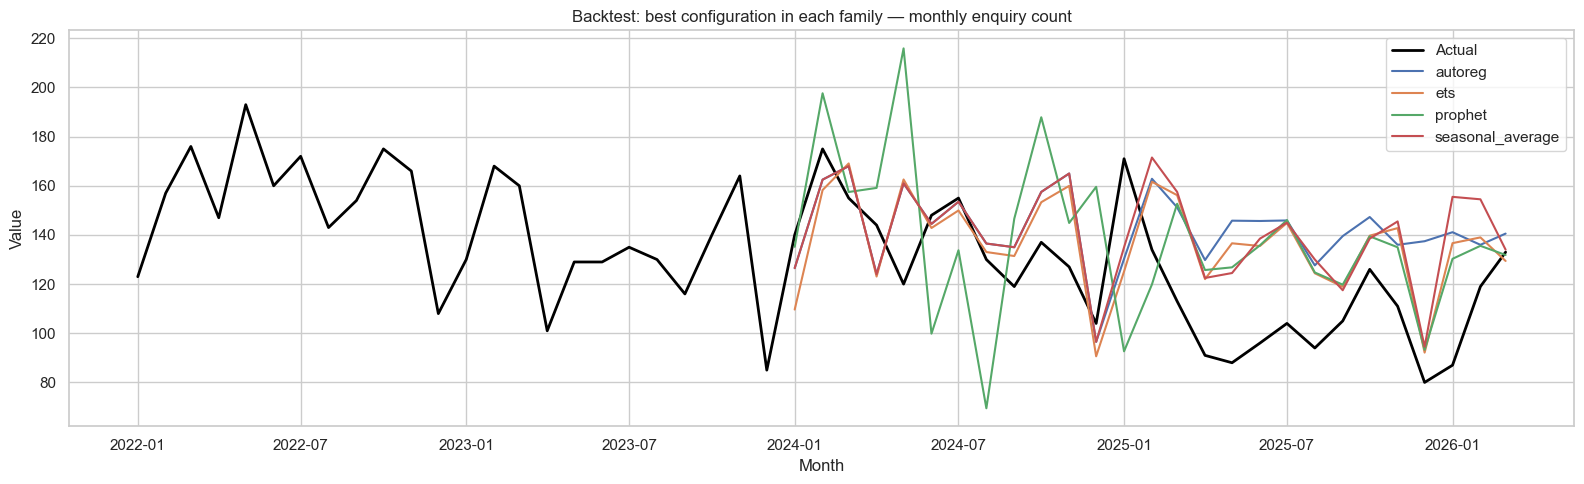

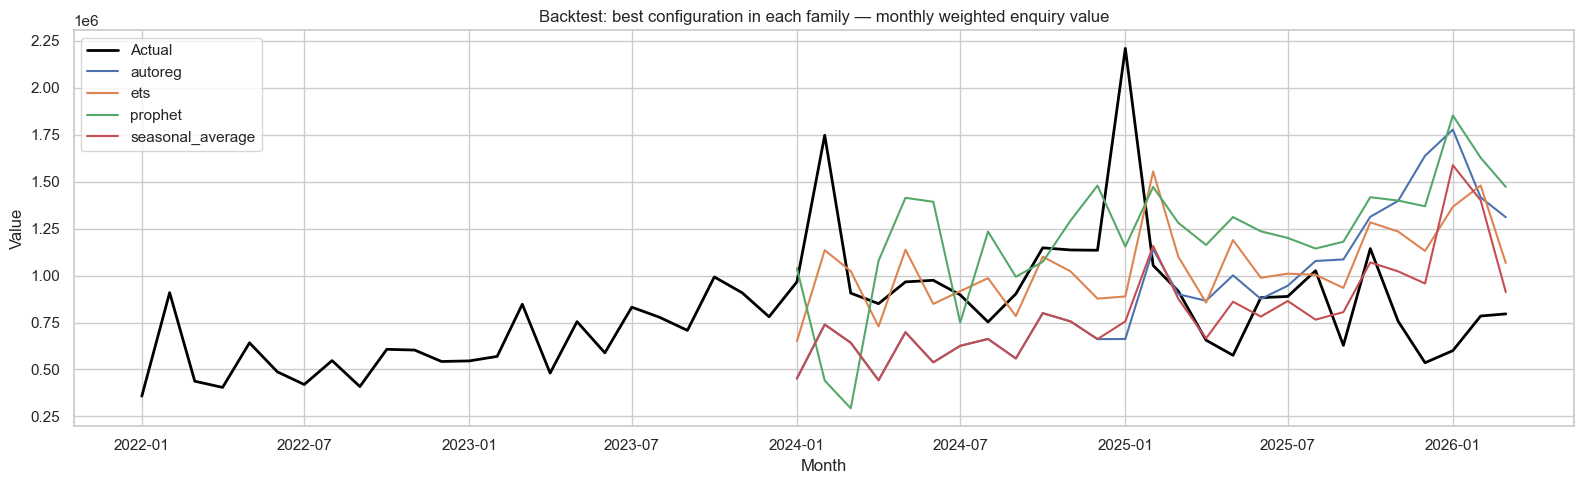

Best model for enquiry count: seasonal_average|{"lookback": 24, "month_bias": false}
Best enquiry count family: seasonal_average
Best enquiry count config: {"lookback": 24, "month_bias": false}
Best model for weighted enquiry value: ets|{"damped": false, "month_bias": false, "remove_bias": false, "seasonal": "add", "trend": null, "use_log": true}
Best weighted enquiry value family: ets
Best weighted enquiry value config: {"damped": false, "month_bias": false, "remove_bias": false, "seasonal": "add", "trend": null, "use_log": true}


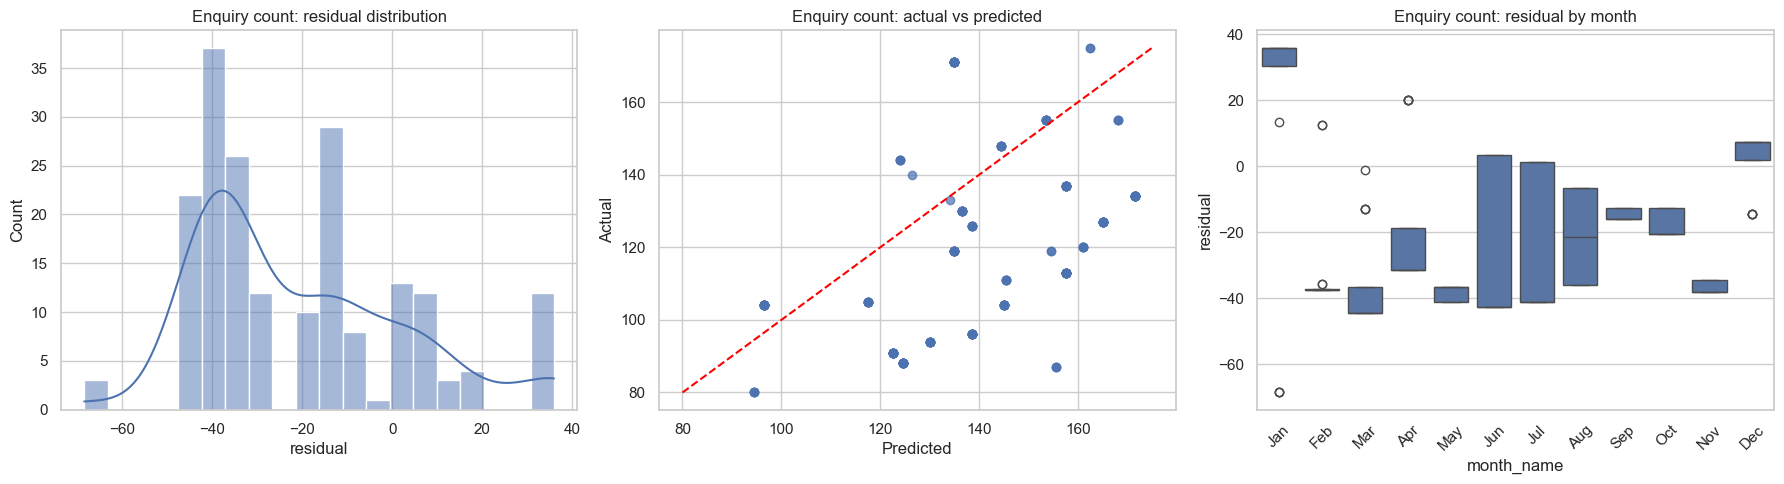

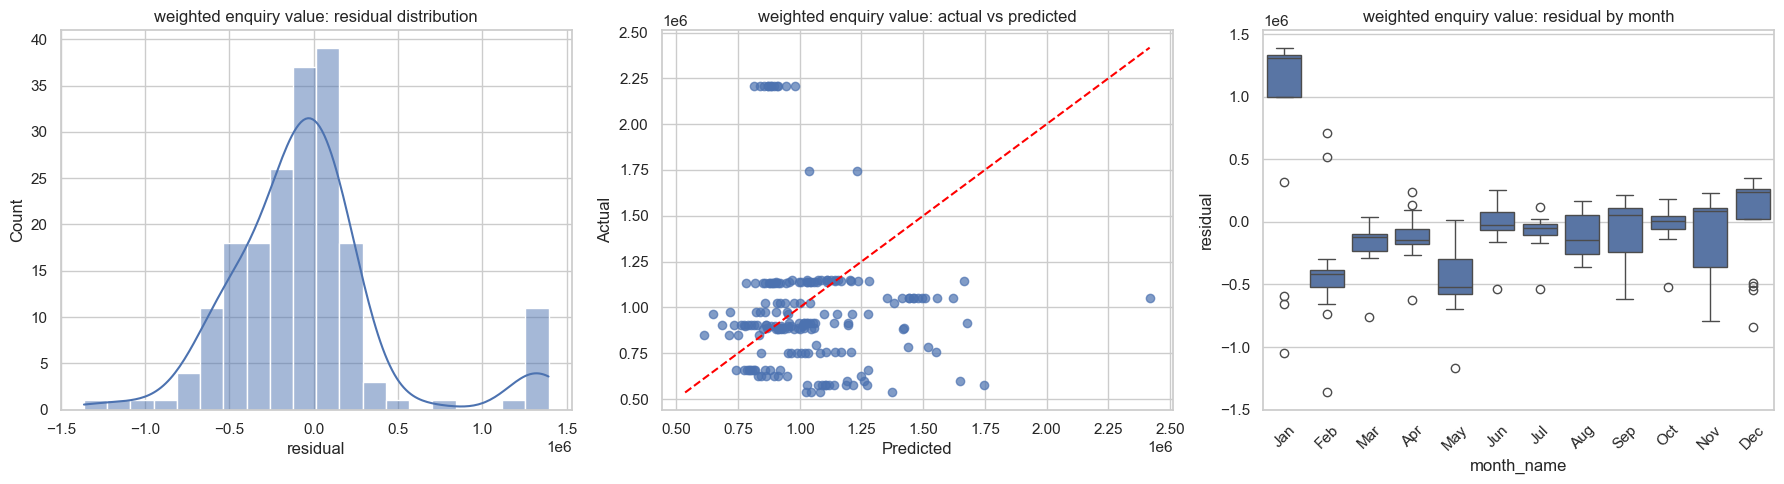

In [9]:
# Visual backtest diagnostics

count_family_best = best_by_family(count_scores)
value_family_best = best_by_family(value_scores)

count_family_backtest_preds = best_family_backtest_preds(count_preds, count_family_best)
value_family_backtest_preds = best_family_backtest_preds(value_preds, value_family_best)

plot_backtest(
    count_series,
    count_family_backtest_preds,
    "Backtest: best configuration in each family — monthly enquiry count",
)
plot_backtest(
    value_series,
    value_family_backtest_preds,
    "Backtest: best configuration in each family — monthly weighted enquiry value",
)

best_count_model = count_scores.iloc[0]["model_label"]
best_value_model = value_scores.iloc[0]["model_label"]

best_count_row = count_scores.iloc[0]
best_value_row = value_scores.iloc[0]

print("Best model for enquiry count:", best_count_model)
print("Best enquiry count family:", best_count_row["family"])
print("Best enquiry count config:", best_count_row["config_json"])

print("Best model for weighted enquiry value:", best_value_model)
print("Best weighted enquiry value family:", best_value_row["family"])
print("Best weighted enquiry value config:", best_value_row["config_json"])

count_best_backtest_preds = count_preds[count_preds["model"] == best_count_model].copy()
value_best_backtest_preds = value_preds[value_preds["model"] == best_value_model].copy()

plot_residual_diagnostics(count_best_backtest_preds, best_count_model, "Enquiry count")
plot_residual_diagnostics(value_best_backtest_preds, best_value_model, "weighted enquiry value")


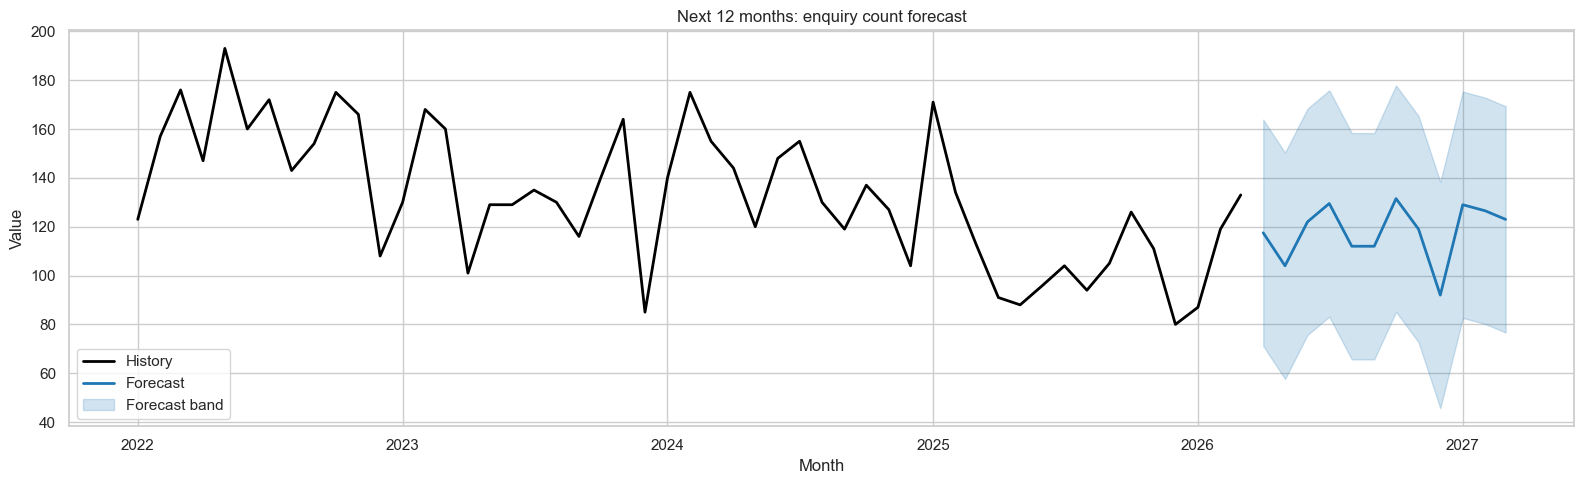

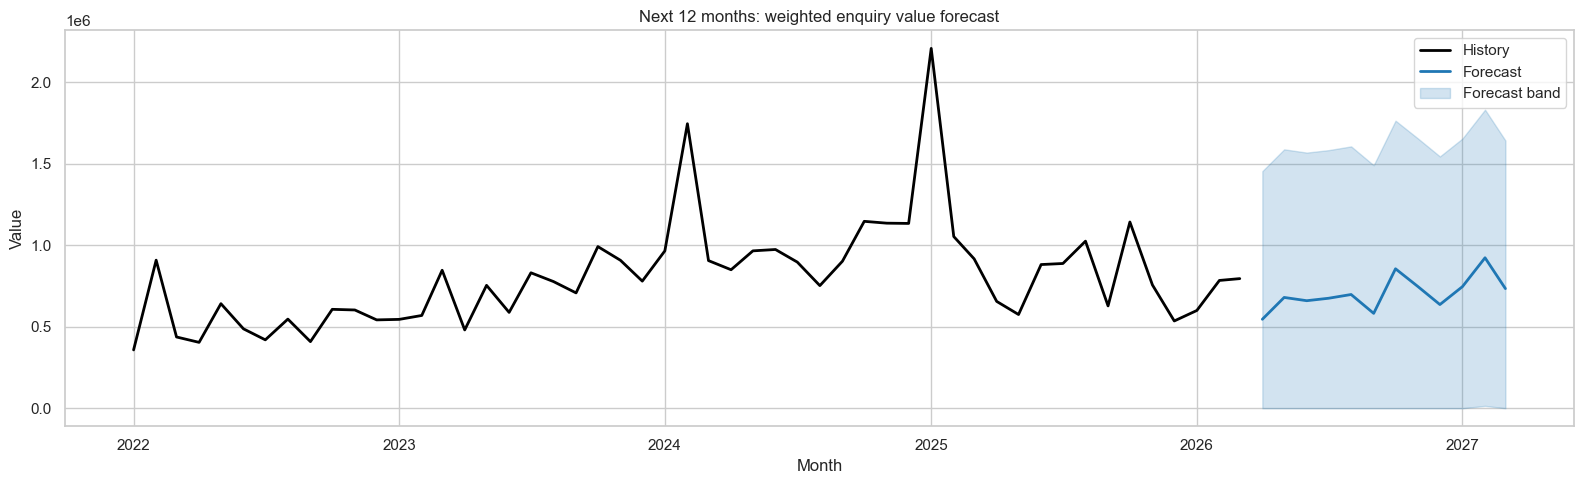

,date,forecast,lower,upper,model
0,2026-04-01,117.5,71.168021,163.831979,"seasonal_average|{""lookback"": 24, ""month_bias""..."
1,2026-05-01,104.0,57.668021,150.331979,"seasonal_average|{""lookback"": 24, ""month_bias""..."
2,2026-06-01,122.0,75.668021,168.331979,"seasonal_average|{""lookback"": 24, ""month_bias""..."
3,2026-07-01,129.5,83.168021,175.831979,"seasonal_average|{""lookback"": 24, ""month_bias""..."
4,2026-08-01,112.0,65.668021,158.331979,"seasonal_average|{""lookback"": 24, ""month_bias""..."
5,2026-09-01,112.0,65.668021,158.331979,"seasonal_average|{""lookback"": 24, ""month_bias""..."
6,2026-10-01,131.5,85.168021,177.831979,"seasonal_average|{""lookback"": 24, ""month_bias""..."
7,2026-11-01,119.0,72.668021,165.331979,"seasonal_average|{""lookback"": 24, ""month_bias""..."
8,2026-12-01,92.0,45.668021,138.331979,"seasonal_average|{""lookback"": 24, ""month_bias""..."
9,2027-01-01,129.0,82.668021,175.331979,"seasonal_average|{""lookback"": 24, ""month_bias""..."


,date,forecast,lower,upper,model
0,2026-04-01,546254.295172,0.000000,1.455485e+06,"ets|{""damped"": false, ""month_bias"": false, ""re..."
1,2026-05-01,680331.101188,0.000000,1.589562e+06,"ets|{""damped"": false, ""month_bias"": false, ""re..."
2,2026-06-01,660318.891152,0.000000,1.569550e+06,"ets|{""damped"": false, ""month_bias"": false, ""re..."
3,2026-07-01,675335.474853,0.000000,1.584566e+06,"ets|{""damped"": false, ""month_bias"": false, ""re..."
4,2026-08-01,698374.534706,0.000000,1.607605e+06,"ets|{""damped"": false, ""month_bias"": false, ""re..."
5,2026-09-01,582593.352916,0.000000,1.491824e+06,"ets|{""damped"": false, ""month_bias"": false, ""re..."
6,2026-10-01,856207.113900,0.000000,1.765438e+06,"ets|{""damped"": false, ""month_bias"": false, ""re..."
7,2026-11-01,746409.545539,0.000000,1.655640e+06,"ets|{""damped"": false, ""month_bias"": false, ""re..."
8,2026-12-01,636665.723038,0.000000,1.545896e+06,"ets|{""damped"": false, ""month_bias"": false, ""re..."
9,2027-01-01,746873.319360,0.000000,1.656104e+06,"ets|{""damped"": false, ""month_bias"": false, ""re..."


In [ ]:
# Final 1-month forecasts

count_forecast = final_forecast(
    count_series,
    count_candidates[best_count_model]["forecaster"],
    best_count_model,
    count_preds,
    horizon=FORECAST_HORIZON,
)
value_forecast = final_forecast(
    value_series,
    value_candidates[best_value_model]["forecaster"],
    best_value_model,
    value_preds,
    horizon=FORECAST_HORIZON,
)

count_forecast.to_csv(OUTPUT_DIR / "overall_count_forecast.csv", index=False)
value_forecast.to_csv(OUTPUT_DIR / "overall_value_forecast.csv", index=False)

plot_final_forecast(count_series, count_forecast, f"Next {FORECAST_HORIZON} months: enquiry count forecast")
plot_final_forecast(value_series, value_forecast, f"Next {FORECAST_HORIZON} months: weighted enquiry value forecast")

display(count_forecast)
display(value_forecast)


In [11]:
# -------------------------------------------------------------------
# Rolling-origin backtests with forecast-step tracking
# -------------------------------------------------------------------

def rolling_origin_predictions(series, forecaster, model_name, initial_train=24, horizon=1, step=1):
    """
    Generate rolling-origin predictions and retain the forecast step
    (1-step ahead, 2-step ahead, ..., horizon-step ahead).

    Returns columns:
        date, actual, pred, model, train_end, forecast_step, origin_start
    """
    series = series.asfreq("MS").fillna(0.0)
    rows = []

    for train_end in range(initial_train, len(series) - horizon + 1, step):
        train = series.iloc[:train_end]
        test = series.iloc[train_end:train_end + horizon]
        pred = forecaster(train, test.index)

        for step_idx, (ds, actual, yhat) in enumerate(zip(test.index, test.values, pred.values), start=1):
            rows.append({
                "date": ds,
                "actual": float(actual),
                "pred": float(yhat),
                "model": model_name,
                "train_end": train.index.max(),
                "origin_start": test.index.min(),
                "forecast_step": step_idx,
            })

    return pd.DataFrame(rows)


# -------------------------------------------------------------------
# Empirical interval estimation from signed residuals
# -------------------------------------------------------------------

def build_empirical_residual_quantiles(
    backtest_df: pd.DataFrame,
    model_name: str,
    horizon: int,
    alpha: float = 0.10,
    min_samples_per_step: int = 8,
) -> pd.DataFrame:
    """
    Build step-specific empirical residual quantiles from rolling-origin backtests.

    residual = actual - pred

    For each forecast step k:
        lower_adjustment = quantile(residuals_k, alpha/2)
        upper_adjustment = quantile(residuals_k, 1 - alpha/2)

    If a given step has too few residuals, fall back to the pooled residual
    distribution across all steps for that model.

    Parameters
    ----------
    backtest_df : pd.DataFrame
        Rolling-origin predictions containing:
        ['actual', 'pred', 'model', 'forecast_step']
    model_name : str
        Selected model label.
    horizon : int
        Forecast horizon to build intervals for.
    alpha : float
        Miscoverage level. Example:
            alpha=0.20 -> 80% interval
            alpha=0.10 -> 90% interval
            alpha=0.05 -> 95% interval
    min_samples_per_step : int
        Minimum number of residuals required before trusting
        a step-specific empirical distribution.

    Returns
    -------
    pd.DataFrame with columns:
        forecast_step, residual_q_low, residual_q_high, n_residuals
    """
    model_backtest = backtest_df[backtest_df["model"] == model_name].copy()
    if model_backtest.empty:
        raise ValueError(f"No backtest rows found for model '{model_name}'.")

    if "forecast_step" not in model_backtest.columns:
        raise ValueError(
            "backtest_df must contain 'forecast_step'. "
            "Rebuild rolling-origin predictions with the updated function."
        )

    model_backtest["residual"] = model_backtest["actual"] - model_backtest["pred"]

    pooled_residuals = model_backtest["residual"].dropna()
    if pooled_residuals.empty:
        raise ValueError(f"No residuals available for model '{model_name}'.")

    pooled_q_low = float(pooled_residuals.quantile(alpha / 2))
    pooled_q_high = float(pooled_residuals.quantile(1 - alpha / 2))

    rows = []
    for step_k in range(1, horizon + 1):
        step_residuals = model_backtest.loc[
            model_backtest["forecast_step"] == step_k, "residual"
        ].dropna()

        if len(step_residuals) >= min_samples_per_step:
            q_low = float(step_residuals.quantile(alpha / 2))
            q_high = float(step_residuals.quantile(1 - alpha / 2))
            n_used = int(len(step_residuals))
        else:
            q_low = pooled_q_low
            q_high = pooled_q_high
            n_used = int(len(step_residuals))

        rows.append({
            "forecast_step": step_k,
            "residual_q_low": q_low,
            "residual_q_high": q_high,
            "n_residuals": n_used,
        })

    return pd.DataFrame(rows)


# -------------------------------------------------------------------
# Final forecast using empirical residual quantiles
# -------------------------------------------------------------------

def final_forecast_empirical_intervals(
    series,
    forecaster,
    model_name,
    backtest_df,
    horizon=6,
    alpha=0.10,
    min_samples_per_step=8,
):
    """
    Produce the final forecast and empirical prediction intervals.

    Interval construction:
        residual = actual - pred
        lower = forecast + q_low(step residuals)
        upper = forecast + q_high(step residuals)

    This is better calibrated than using a single global residual std,
    because uncertainty is allowed to vary by forecast step.
    """
    series = series.asfreq("MS").fillna(0.0)

    future_index = pd.date_range(
        series.index.max() + pd.offsets.MonthBegin(1),
        periods=horizon,
        freq="MS",
    )

    pred = forecaster(series, future_index)
    pred = pd.Series(np.asarray(pred, dtype=float), index=future_index)

    interval_table = build_empirical_residual_quantiles(
        backtest_df=backtest_df,
        model_name=model_name,
        horizon=horizon,
        alpha=alpha,
        min_samples_per_step=min_samples_per_step,
    )

    forecast_steps = np.arange(1, horizon + 1)

    lower_adjustment = pd.Series(
        interval_table["residual_q_low"].values,
        index=future_index,
        dtype=float,
    )
    upper_adjustment = pd.Series(
        interval_table["residual_q_high"].values,
        index=future_index,
        dtype=float,
    )

    lower = pred + lower_adjustment
    upper = pred + upper_adjustment

    lower = non_negative(lower)
    upper = non_negative(upper)

    # Ensure monotonic interval ordering after clipping
    lower, upper = np.minimum(lower, upper), np.maximum(lower, upper)
    lower = pd.Series(lower, index=future_index, dtype=float)
    upper = pd.Series(upper, index=future_index, dtype=float)

    forecast_df = pd.DataFrame({
        "date": future_index,
        "forecast_step": forecast_steps,
        "forecast": pred.values,
        "lower": lower.values,
        "upper": upper.values,
        "model": model_name,
        "alpha": alpha,
    })

    return forecast_df, interval_table

In [12]:
def ensure_forecast_step(backtest_df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure rolling-origin backtest output has 'forecast_step'.
    Works with both old schema (no forecast_step) and new schema.
    """
    out = backtest_df.copy()

    if "forecast_step" not in out.columns:
        out["date"] = pd.to_datetime(out["date"])
        out["train_end"] = pd.to_datetime(out["train_end"])

        out["forecast_step"] = (
            (out["date"].dt.year - out["train_end"].dt.year) * 12
            + (out["date"].dt.month - out["train_end"].dt.month)
        ).astype(int)

        if (out["forecast_step"] <= 0).any():
            raise ValueError("Computed non-positive forecast_step values from date/train_end.")

    return out


count_preds_fs = ensure_forecast_step(count_preds)
value_preds_fs = ensure_forecast_step(value_preds)

count_forecast, count_interval_table = final_forecast_empirical_intervals(
    count_series,
    count_candidates[best_count_model]["forecaster"],
    best_count_model,
    count_preds_fs,
    horizon=FORECAST_HORIZON,
    alpha=0.10,              # 80% interval
    min_samples_per_step=8,
)

value_forecast, value_interval_table = final_forecast_empirical_intervals(
    value_series,
    value_candidates[best_value_model]["forecaster"],
    best_value_model,
    value_preds_fs,
    horizon=FORECAST_HORIZON,
    alpha=0.10,              # change to 0.10 or 0.05 if you want wider bands
    min_samples_per_step=8,
)

display(count_interval_table)
display(value_interval_table)
display(count_forecast)
display(value_forecast)

,forecast_step,residual_q_low,residual_q_high,n_residuals
0,1,-41.875,24.000,16
1,2,-41.875,24.000,16
2,3,-43.000,24.000,16
3,4,-43.000,24.000,16
4,5,-43.000,14.625,16
5,6,-43.000,14.625,16
6,7,-43.000,14.625,16
7,8,-43.000,14.625,16
8,9,-43.000,14.625,16
9,10,-50.500,14.625,16


,forecast_step,residual_q_low,residual_q_high,n_residuals
0,1,-556418.341224,694102.567101,16
1,2,-649219.110177,854644.165700,16
2,3,-640515.698958,523341.882307,16
3,4,-598482.381340,571825.116225,16
4,5,-562005.475061,532524.507490,16
5,6,-540271.149226,523308.265447,16
6,7,-437258.953145,535091.163977,16
7,8,-542243.139319,506397.934588,16
8,9,-496212.608551,518684.519661,16
9,10,-640839.797029,477690.162029,16


,date,forecast_step,forecast,lower,upper,model,alpha
0,2026-04-01,1,117.5,75.625,141.500,"seasonal_average|{""lookback"": 24, ""month_bias""...",0.1
1,2026-05-01,2,104.0,62.125,128.000,"seasonal_average|{""lookback"": 24, ""month_bias""...",0.1
2,2026-06-01,3,122.0,79.000,146.000,"seasonal_average|{""lookback"": 24, ""month_bias""...",0.1
3,2026-07-01,4,129.5,86.500,153.500,"seasonal_average|{""lookback"": 24, ""month_bias""...",0.1
4,2026-08-01,5,112.0,69.000,126.625,"seasonal_average|{""lookback"": 24, ""month_bias""...",0.1
5,2026-09-01,6,112.0,69.000,126.625,"seasonal_average|{""lookback"": 24, ""month_bias""...",0.1
6,2026-10-01,7,131.5,88.500,146.125,"seasonal_average|{""lookback"": 24, ""month_bias""...",0.1
7,2026-11-01,8,119.0,76.000,133.625,"seasonal_average|{""lookback"": 24, ""month_bias""...",0.1
8,2026-12-01,9,92.0,49.000,106.625,"seasonal_average|{""lookback"": 24, ""month_bias""...",0.1
9,2027-01-01,10,129.0,78.500,143.625,"seasonal_average|{""lookback"": 24, ""month_bias""...",0.1


,date,forecast_step,forecast,lower,upper,model,alpha
0,2026-04-01,1,546254.295172,0.000000,1.240357e+06,"ets|{""damped"": false, ""month_bias"": false, ""re...",0.1
1,2026-05-01,2,680331.101188,31111.991011,1.534975e+06,"ets|{""damped"": false, ""month_bias"": false, ""re...",0.1
2,2026-06-01,3,660318.891152,19803.192194,1.183661e+06,"ets|{""damped"": false, ""month_bias"": false, ""re...",0.1
3,2026-07-01,4,675335.474853,76853.093513,1.247161e+06,"ets|{""damped"": false, ""month_bias"": false, ""re...",0.1
4,2026-08-01,5,698374.534706,136369.059645,1.230899e+06,"ets|{""damped"": false, ""month_bias"": false, ""re...",0.1
5,2026-09-01,6,582593.352916,42322.203690,1.105902e+06,"ets|{""damped"": false, ""month_bias"": false, ""re...",0.1
6,2026-10-01,7,856207.113900,418948.160755,1.391298e+06,"ets|{""damped"": false, ""month_bias"": false, ""re...",0.1
7,2026-11-01,8,746409.545539,204166.406220,1.252807e+06,"ets|{""damped"": false, ""month_bias"": false, ""re...",0.1
8,2026-12-01,9,636665.723038,140453.114487,1.155350e+06,"ets|{""damped"": false, ""month_bias"": false, ""re...",0.1
9,2027-01-01,10,746873.319360,106033.522330,1.224563e+06,"ets|{""damped"": false, ""month_bias"": false, ""re...",0.1


In [13]:
def plot_final_forecast(history, forecast_df, title):
    plt.figure(figsize=(16, 5))
    plt.plot(history.index, history.values, color="black", linewidth=2, label="History")
    plt.plot(forecast_df["date"], forecast_df["forecast"], color="tab:blue", linewidth=2, label="Forecast")
    plt.fill_between(
        forecast_df["date"],
        forecast_df["lower"],
        forecast_df["upper"],
        color="tab:blue",
        alpha=0.10,
        label="Forecast band",
    )
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

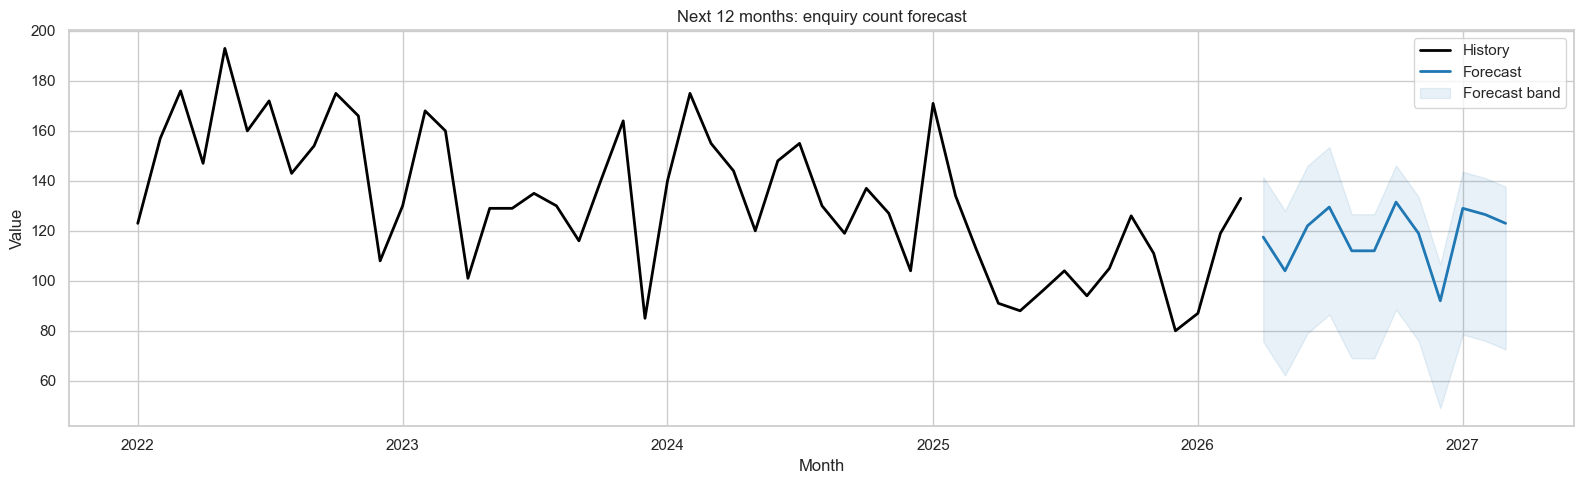

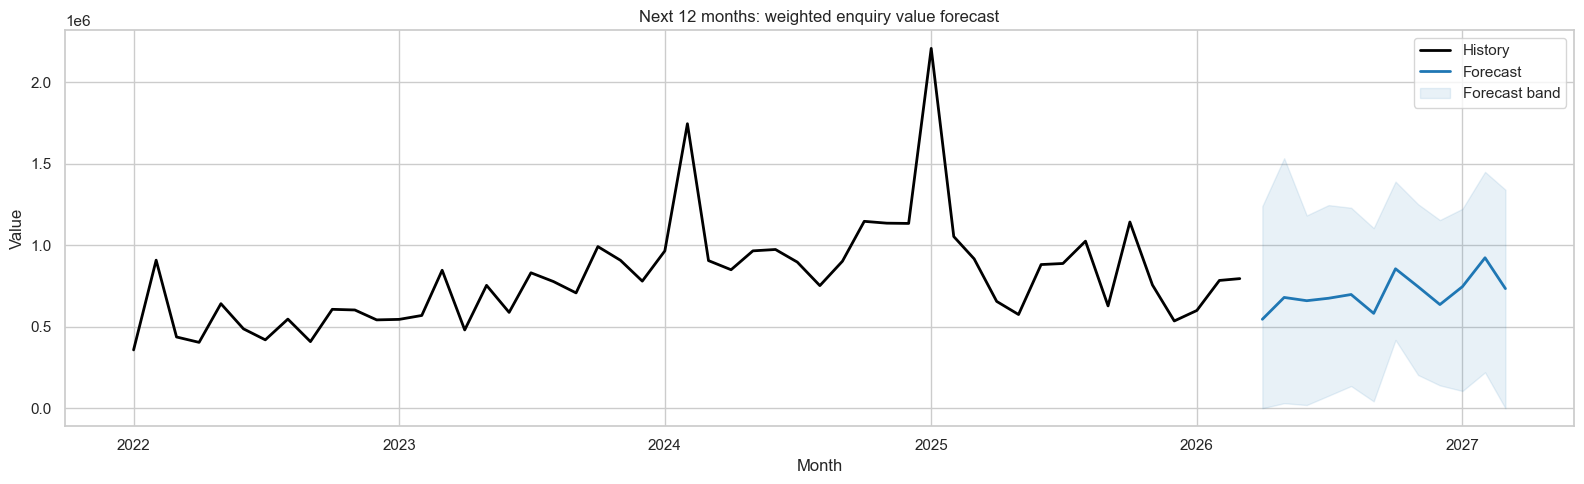

In [14]:
plot_final_forecast(
    count_series,
    count_forecast,
    f"Next {FORECAST_HORIZON} months: enquiry count forecast"
)

plot_final_forecast(
    value_series,
    value_forecast,
    f"Next {FORECAST_HORIZON} months: weighted enquiry value forecast"
)

In [15]:
# Save a compact model-selection summary

summary_rows = [
    {
        "target": "overall_enquiry_count",
        "best_model": best_count_model,
        "best_family": best_count_row["family"],
        "best_config_json": best_count_row["config_json"],
        "rmse": best_count_row["rmse"],
        "mae": best_count_row["mae"],
        "mape": best_count_row["mape"],
        "smape": best_count_row["smape"],
    },
    {
        "target": "overall_weighted_enquiry_value",
        "best_model": best_value_model,
        "best_family": best_value_row["family"],
        "best_config_json": best_value_row["config_json"],
        "rmse": best_value_row["rmse"],
        "mae": best_value_row["mae"],
        "mape": best_value_row["mape"],
        "smape": best_value_row["smape"],
    },
]

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR / "overall_best_model_summary.csv", index=False)
display(summary_df)


,target,best_model,best_family,best_config_json,rmse,mae,mape,smape
0,overall_enquiry_count,"seasonal_average|{""lookback"": 24, ""month_bias""...",seasonal_average,"{""lookback"": 24, ""month_bias"": false}",31.144196,27.348958,24.618206,21.467859
1,overall_weighted_enquiry_value,"ets|{""damped"": false, ""month_bias"": false, ""re...",ets,"{""damped"": false, ""month_bias"": false, ""remove...",465458.135512,314928.015585,33.335339,28.788991
